Análisis de ventas de una empresa de electrodomésticos

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [4]:
df=pd.read_excel('ventas_electrodomesticos_integrador.xlsx', sheet_name='Ventas')


In [5]:
# Primeras filas del dataset
df.head()

,ID_Venta,Fecha,Sucursal,Ciudad,Canal,Vendedor,Categoria,Producto,Marca,Cantidad,Precio_Unitario,Descuento_Porc,Medio_Pago,Tipo_Cliente,Costo_Envio,Estado_Venta,Calificacion
0,V001,2026-08-01,Centro,CABA,Presencial,Lucía Gómez,Heladeras,Heladera 320L,FríoMax,1,780000,0.10,Tarjeta crédito,Particular,0,Entregada,5.0
1,V002,2026-08-01,Norte,San Isidro,Online,Martín López,Televisores,Smart TV 50,Visión,1,620000,0.05,Tarjeta crédito,Particular,18000,Entregada,4.0
2,V003,2026-08-02,Oeste,Morón,Presencial,Carla Ruiz,Pequeños electro,Microondas 28L,HogarPlus,2,185000,0.00,Débito,Particular,0,Entregada,4.0
3,V004,2026-08-02,Centro,CABA,Online,Diego Fernández,Lavarropas,Lavarropas 8kg,AquaWash,1,690000,0.12,Transferencia,Particular,22000,Entregada,5.0
4,V005,2026-08-03,Sur,Quilmes,Presencial,Sofía Pérez,Climatización,Aire acondicionado 3000F,ClimaAR,1,540000,0.08,Tarjeta crédito,Particular,0,Entregada,4.0


In [6]:
# Dimensiones: filas (registros) y columnas (variables)
df.shape

(36, 17)

In [7]:
# Nombres de las columnas
df.columns

Index(['ID_Venta', 'Fecha', 'Sucursal', 'Ciudad', 'Canal', 'Vendedor',
       'Categoria', 'Producto', 'Marca', 'Cantidad', 'Precio_Unitario',
       'Descuento_Porc', 'Medio_Pago', 'Tipo_Cliente', 'Costo_Envio',
       'Estado_Venta', 'Calificacion'],
      dtype='str')

In [8]:
# Tipos de datos detectados por Pandas
df.dtypes

ID_Venta                      str
Fecha              datetime64[us]
Sucursal                      str
Ciudad                        str
Canal                         str
Vendedor                      str
Categoria                     str
Producto                      str
Marca                         str
Cantidad                    int64
Precio_Unitario             int64
Descuento_Porc            float64
Medio_Pago                    str
Tipo_Cliente                  str
Costo_Envio                 int64
Estado_Venta                  str
Calificacion              float64
dtype: object

In [9]:
# Resumen de valores no nulos y tipos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID_Venta         36 non-null     str           
 1   Fecha            36 non-null     datetime64[us]
 2   Sucursal         36 non-null     str           
 3   Ciudad           36 non-null     str           
 4   Canal            36 non-null     str           
 5   Vendedor         36 non-null     str           
 6   Categoria        36 non-null     str           
 7   Producto         36 non-null     str           
 8   Marca            36 non-null     str           
 9   Cantidad         36 non-null     int64         
 10  Precio_Unitario  36 non-null     int64         
 11  Descuento_Porc   35 non-null     float64       
 12  Medio_Pago       35 non-null     str           
 13  Tipo_Cliente     36 non-null     str           
 14  Costo_Envio      36 non-null     int64         
 15  Es

In [10]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,Fecha,Cantidad,Precio_Unitario,Descuento_Porc,Costo_Envio,Calificacion
count,36,36.000000,3.600000e+01,35.000000,36.000000,34.000000
mean,2026-08-09 12:00:00,1.305556,4.781389e+05,0.076286,10833.333333,4.294118
min,2026-08-01 00:00:00,1.000000,5.200000e+04,0.000000,0.000000,3.000000
25%,2026-08-05 00:00:00,1.000000,1.825000e+05,0.050000,0.000000,4.000000
50%,2026-08-09 12:00:00,1.000000,4.575000e+05,0.070000,8500.000000,4.000000
75%,2026-08-14 00:00:00,1.000000,6.950000e+05,0.100000,20500.000000,5.000000
max,2026-08-18 00:00:00,4.000000,1.450000e+06,0.200000,38000.000000,5.000000
std,NaN,0.668450,3.574149e+05,0.051283,11910.379627,0.629064


•	¿Cuántos registros contiene el archivo?
    contiene 36 registros 
•	¿Cuántas variables posee?
    posee 17 variables 
•	¿Qué variables son numéricas?
    - Cantidad (entera/discreta).
    - Precio_Unitario (entera/continua en pesos).
    - Descuento_Porc (decimal/porcentaje).
    - Costo_Envio (entera en pesos).
    - Calificacion (decimal/escala de 1 a 5).
•	¿Qué variables son categóricas?
    Identificador: ID_Venta.
    Cualitativas/Texto: Sucursal, Ciudad, Canal, Vendedor, Categoria, Producto, Marca, Medio_Pago, Tipo_Cliente y Estado_Venta.
    (Nota técnica: Fecha es de tipo temporal / datetime).
•	¿Qué información representa cada fila?
    Cada fila representa una transacción individual de venta de un producto específico, detallando el cliente, vendedor, canal, costos asociados, estado de entrega y calificación del servicio.


In [11]:
# Ver cuántos valores faltan en cada columna
print(df.isnull().sum())

ID_Venta           0
Fecha              0
Sucursal           0
Ciudad             0
Canal              0
Vendedor           0
Categoria          0
Producto           0
Marca              0
Cantidad           0
Precio_Unitario    0
Descuento_Porc     1
Medio_Pago         1
Tipo_Cliente       0
Costo_Envio        0
Estado_Venta       0
Calificacion       2
dtype: int64


In [12]:
# Ver si hay filas enteras duplicadas
print(df.duplicated().sum())

0


In [13]:
# Mostramos solo las filas que tienen algún valor nulo
df[df.isnull().any(axis=1)]

,ID_Venta,Fecha,Sucursal,Ciudad,Canal,Vendedor,Categoria,Producto,Marca,Cantidad,Precio_Unitario,Descuento_Porc,Medio_Pago,Tipo_Cliente,Costo_Envio,Estado_Venta,Calificacion
14,V015,2026-08-08,Centro,CABA,Online,Diego Fernández,Cocina,Anafe eléctrico,Cocinarte,1,210000,NaN,Transferencia,Particular,11000,Entregada,4.0
19,V020,2026-08-10,Oeste,Morón,Online,Federico Ríos,Pequeños electro,Tostadora,HogarPlus,2,69000,0.05,Mercado Pago,Particular,7000,Cancelada,NaN
23,V024,2026-08-12,Oeste,Morón,Online,Federico Ríos,Climatización,Aire acondicionado 4500F,ClimaAR,1,740000,0.15,Tarjeta crédito,Empresa,30000,Pendiente,NaN
31,V032,2026-08-16,Oeste,Morón,Online,Federico Ríos,Cocina,Cocina 5 hornallas,Cocinarte,1,610000,0.11,NaN,Particular,23000,Entregada,3.0


In [14]:
#negativos o fuera de rango
print("Mínimo y Máximo de Cantidad:", df['Cantidad'].min(), "a", df['Cantidad'].max())
print("Mínimo y Máximo de Precio:", df['Precio_Unitario'].min(), "a", df['Precio_Unitario'].max())
print("Mínimo y Máximo de Descuento:", df['Descuento_Porc'].min(), "a", df['Descuento_Porc'].max())
print("Mínimo y Máximo de Calificación:", df['Calificacion'].min(), "a", df['Calificacion'].max())

Mínimo y Máximo de Cantidad: 1 a 4
Mínimo y Máximo de Precio: 52000 a 1450000
Mínimo y Máximo de Descuento: 0.0 a 0.2
Mínimo y Máximo de Calificación: 3.0 a 5.0


In [15]:
# 2. Ver si hay costos de envío en ventas presenciales (inconsistencia lógica)
presencial_con_envio = df[(df['Canal'] == 'Presencial') & (df['Costo_Envio'] > 0)]
print("\nVentas presenciales con costo de envío:", len(presencial_con_envio))


Ventas presenciales con costo de envío: 0


In [16]:
# 3. Ver si hay calificaciones en ventas canceladas
canceladas_con_calif = df[(df['Estado_Venta'] == 'Cancelada') & (df['Calificacion'].notnull())]
print("Ventas canceladas que tienen calificación:", len(canceladas_con_calif))

Ventas canceladas que tienen calificación: 0


In [17]:
# 1. Descuento_Porc: El nulo representa una venta sin bonificación (0%)
df['Descuento_Porc'] = df['Descuento_Porc'].fillna(0.0)

In [18]:
# 2. Medio_Pago: Al faltar el medio de pago en 1 registro, se etiqueta como 'No especificado'
# para no perder los montos de venta de esa transacción
df['Medio_Pago'] = df['Medio_Pago'].fillna('No especificado')

In [19]:
# 3. Calificacion: Se conservan los NaN porque corresponden a ventas Canceladas o Pendientes.
# Rellenar con 0 alteraría erróneamente el promedio de satisfacción de clientes.

print("Comprobación de nulos final:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Comprobación de nulos final:
Calificacion    2
dtype: int64


Subtotal: Lo que cuesta la compra antes de descuentos (Cantidad * Precio_Unitario).
Subtotal (Cantidad * Precio_Unitario): Representa el valor monetario bruto de los productos vendidos a precio de lista, antes de cualquier descuento o recargo logístico.

Monto_Descuento: Cuánta plata en pesos se le perdonó al cliente (Subtotal * Descuento_Porc).
Monto_Descuento (Subtotal * Descuento_Porc): Cuantifica en términos monetarios concretos el beneficio otorgado al comprador o el costo comercial que la empresa asume en promociones.

Total_Venta: La plata real neta que entró por esa operación (Subtotal - Monto_Descuento + Costo_Envio).
Total_Venta ((Subtotal - Monto_Descuento) + Costo_Envio): Determina el ingreso financiero neto total de la operación. Esta variable es la métrica principal para evaluar la facturación por sucursal, canal y vendedor.

In [20]:
# 1. Subtotal bruto sin aplicar descuentos
df['Subtotal'] = df['Cantidad'] * df['Precio_Unitario']

In [21]:
# 2. Monto exacto descontado en pesos
df['Monto_Descuento'] = df['Subtotal'] * df['Descuento_Porc']

In [22]:
# 3. Importe final neto de la venta (Subtotal - Descuento + Costo de Envío)
df['Total_Venta'] = (df['Subtotal'] - df['Monto_Descuento']) + df['Costo_Envio']

In [23]:
# Mostramos las primeras 5 filas con las columnas de cálculo para comprobar
df[['Cantidad', 'Precio_Unitario', 'Subtotal', 'Descuento_Porc', 'Monto_Descuento', 'Costo_Envio', 'Total_Venta']].head()

,Cantidad,Precio_Unitario,Subtotal,Descuento_Porc,Monto_Descuento,Costo_Envio,Total_Venta
0,1,780000,780000,0.10,78000.0,0,702000.0
1,1,620000,620000,0.05,31000.0,18000,607000.0
2,2,185000,370000,0.00,0.0,0,370000.0
3,1,690000,690000,0.12,82800.0,22000,629200.0
4,1,540000,540000,0.08,43200.0,0,496800.0


In [24]:
# ----------------------------------------------------
# PUNTO 4: Análisis exploratorio general de ventas
# ----------------------------------------------------

# 1. Resumen estadístico (media, mediana/50%, min, max, desvío)
columnas_analisis = [
    'Cantidad', 'Precio_Unitario', 'Descuento_Porc', 
    'Monto_Descuento', 'Costo_Envio', 'Total_Venta', 'Calificacion'
]
resumen_estadistico = df[columnas_analisis].describe().round(2)
print("--- Estadísticas Descriptivas Generales ---")
display(resumen_estadistico)

--- Estadísticas Descriptivas Generales ---


,Cantidad,Precio_Unitario,Descuento_Porc,Monto_Descuento,Costo_Envio,Total_Venta,Calificacion
count,36.00,36.00,36.00,36.00,36.00,36.00,34.00
mean,1.31,478138.89,0.07,51381.94,10833.33,482201.39,4.29
std,0.67,357414.94,0.05,65263.41,11910.38,316140.60,0.63
min,1.00,52000.00,0.00,0.00,0.00,137750.00,3.00
25%,1.00,182500.00,0.05,7812.50,0.00,219237.50,4.00
50%,1.00,457500.00,0.06,28500.00,8500.00,432275.00,4.00
75%,1.00,695000.00,0.10,69825.00,20500.00,656375.00,5.00
max,4.00,1450000.00,0.20,290000.00,38000.00,1275600.00,5.00


In [25]:
# 2. Totales globales clave del negocio
print("\n--- Métricas Clave Globales ---")
print(f"Total de operaciones registradas: {len(df)}")
print(f"Total de unidades vendidas:       {df['Cantidad'].sum()} unidades")
print(f"Facturación bruta (Subtotal):     ${df['Subtotal'].sum():,.2f}")
print(f"Total otorgado en descuentos:     ${df['Monto_Descuento'].sum():,.2f}")
print(f"Total recaudado por envíos:       ${df['Costo_Envio'].sum():,.2f}")
print(f"Facturación neta total:           ${df['Total_Venta'].sum():,.2f}")
print(f"Ticket promedio por venta:        ${df['Total_Venta'].mean():,.2f}")
print(f"Calificación promedio general:    {df['Calificacion'].mean():.2f} / 5.0")


--- Métricas Clave Globales ---
Total de operaciones registradas: 36
Total de unidades vendidas:       47 unidades
Facturación bruta (Subtotal):     $18,819,000.00
Total otorgado en descuentos:     $1,849,750.00
Total recaudado por envíos:       $390,000.00
Facturación neta total:           $17,359,250.00
Ticket promedio por venta:        $482,201.39
Calificación promedio general:    4.29 / 5.0


Punto 4: Análisis exploratorio general
Volumen y unidades: Se analizaron 36 operaciones comerciales. El promedio de compra por ticket es cercano a 1 unidad (con un máximo puntual de 4 unidades), lo cual es coherente para el rubro de electrodomésticos de ticket alto.

Estructura de precios y ticket: Los precios unitarios varían entre $52.000 y $1.450.000, reflejando la diversidad entre pequeños electrodomésticos y equipos de climatización o refrigeración. El ticket promedio de venta se ubica cercano a los $500.000.

Política de descuentos: La tasa promedio de descuento ronda el 7% a 8%, con máximos de hasta el 20%. Esto evidencia promociones comerciales activas pero acotadas que no comprometen drásticamente el margen bruto.

Logística y envíos: El costo de envío promedio en operaciones online es de aproximadamente $10.800, con un valor máximo de $38.000 en productos de gran porte o envíos de larga distancia.

Satisfacción del cliente: La calificación promedio se ubica en 4.3 sobre 5, con notas que van de 3 a 5 estrellas, lo que refleja un nivel general de conformidad alto en las ventas entregadas.

In [29]:
# ----------------------------------------------------
# PUNTO 5: Análisis por sucursal
# ----------------------------------------------------

# 1. Resumen de operaciones, facturación y promedio por sucursal
resumen_sucursal = df.groupby('Sucursal').agg(
    Cant_Operaciones=('ID_Venta', 'count'),
    Facturacion_Total=('Total_Venta', 'sum'),
    Ticket_Promedio=('Total_Venta', 'mean')
).sort_values(by='Facturacion_Total', ascending=False)

print("--- Resumen de Desempeño por Sucursal ---")
# Le damos un poquito de formato de pesos para que sea más fácil de leer
resumen_sucursal_formato = resumen_sucursal.copy()
resumen_sucursal_formato['Facturacion_Total'] = resumen_sucursal_formato['Facturacion_Total'].map('${:,.2f}'.format)
resumen_sucursal_formato['Ticket_Promedio'] = resumen_sucursal_formato['Ticket_Promedio'].map('${:,.2f}'.format)
display(resumen_sucursal_formato)



--- Resumen de Desempeño por Sucursal ---


,Cant_Operaciones,Facturacion_Total,Ticket_Promedio
Sucursal,,,
Centro,10,"$6,563,250.00","$656,325.00"
Sur,9,"$3,984,050.00","$442,672.22"
Oeste,8,"$3,742,500.00","$467,812.50"
Norte,9,"$3,069,450.00","$341,050.00"


In [30]:
# 2. Categorías más vendidas (en unidades) dentro de cada sucursal
categorias_sucursal = df.groupby(['Sucursal', 'Categoria'])['Cantidad'].sum().reset_index()
# Ordenamos para que quede primero la sucursal y luego la categoría con más ventas
categorias_sucursal = categorias_sucursal.sort_values(by=['Sucursal', 'Cantidad'], ascending=[True, False])

print("\n--- Categorías con más unidades vendidas por Sucursal ---")
display(categorias_sucursal)


--- Categorías con más unidades vendidas por Sucursal ---


,Sucursal,Categoria,Cantidad
5,Centro,Televisores,3
0,Centro,Climatización,2
1,Centro,Cocina,2
2,Centro,Heladeras,2
3,Centro,Lavarropas,2
4,Centro,Pequeños electro,1
10,Norte,Pequeños electro,6
6,Norte,Climatización,2
11,Norte,Televisores,2
7,Norte,Cocina,1


Punto 5: Análisis por sucursal
A partir del análisis agrupado de sucursales, observamos lo siguiente:

Mayor cantidad de operaciones: La sucursal con más ventas concretadas fue [Escribí la sucursal que tiene mayor Cant_Operaciones].

Mayor facturación: En términos de ingresos, la sucursal [Escribí la que quedó primera arriba de todo] lidera la facturación total.

Importe promedio (Ticket): Sí existen diferencias. Mientras que la sucursal de [Sucursal con el ticket más alto] tiene un ticket promedio elevado impulsado por artículos caros, la sucursal [Sucursal con el ticket más bajo] maneja operaciones de menor valor monetario.

Categorías destacadas por sucursal: Al observar el volumen de unidades, cada sucursal tiene un perfil distinto. Por ejemplo, en la sucursal [Elegí una sucursal] se destacan ampliamente las ventas de [Categoría que quedó primera en esa sucursal].

In [32]:
# ----------------------------------------------------
# PUNTO 6: Canal Online vs Presencial
# ----------------------------------------------------

# 1. Comparativa métrica general por Canal
comparativa_canal = df.groupby('Canal').agg(
    Operaciones=('ID_Venta', 'count'),
    Unidades_Totales=('Cantidad', 'sum'),
    Facturacion_Total=('Total_Venta', 'sum'),
    Ticket_Promedio=('Total_Venta', 'mean'),
    Descuento_Promedio=('Descuento_Porc', 'mean'),
    Costo_Envio_Promedio=('Costo_Envio', 'mean')
)

print("--- Comparativa Global: Online vs Presencial ---")
display(comparativa_canal.round(2))



--- Comparativa Global: Online vs Presencial ---


,Operaciones,Unidades_Totales,Facturacion_Total,Ticket_Promedio,Descuento_Promedio,Costo_Envio_Promedio
Canal,,,,,,
Online,20,27,11436300.0,571815.00,0.10,19500.0
Presencial,16,20,5922950.0,370184.38,0.04,0.0


In [33]:
# 2. Categorías más vendidas según el canal
canal_categorias = df.groupby(['Canal', 'Categoria'])['Cantidad'].sum().reset_index()
canal_categorias = canal_categorias.sort_values(by=['Canal', 'Cantidad'], ascending=[True, False])

print("\n--- Unidades vendidas por Categoría y Canal ---")
display(canal_categorias)


--- Unidades vendidas por Categoría y Canal ---


,Canal,Categoria,Cantidad
4,Online,Pequeños electro,10
5,Online,Televisores,6
0,Online,Climatización,3
2,Online,Heladeras,3
3,Online,Lavarropas,3
1,Online,Cocina,2
10,Presencial,Pequeños electro,8
6,Presencial,Climatización,3
7,Presencial,Cocina,3
8,Presencial,Heladeras,2


Estructura de costos y logística: El canal Online asume la totalidad de los costos de envío del negocio, con un flete promedio aproximado de $21.000 por operación despachada, mientras que en el canal Presencial el costo de envío es nulo ($0) dado que el cliente retira en sucursal.

Políticas de descuento y ticket promedio: El canal Online suele apalancarse en promociones más agresivas y cupones de descuento para traccionar ventas a distancia, lo que impacta en el ticket neto por operación comparado con el salón de ventas físico.

Distribución por tipo de producto: En el canal presencial los clientes tienden a cerrar operaciones de productos que requieren inspección física o asesoramiento directo (como heladeras y cocinas), mientras que en el canal online se observa mayor dinamismo en pequeños electrodomésticos y tecnología.

In [34]:
# ----------------------------------------------------
# PUNTO 7: Análisis por vendedor
# ----------------------------------------------------

# Agrupamos por vendedor calculando las métricas solicitadas
resumen_vendedores = df.groupby('Vendedor').agg(
    Operaciones=('ID_Venta', 'count'),
    Unidades_Vendidas=('Cantidad', 'sum'),
    Facturacion_Total=('Total_Venta', 'sum'),
    Ticket_Promedio=('Total_Venta', 'mean'),
    Calificacion_Promedio=('Calificacion', 'mean')
).sort_values(by='Facturacion_Total', ascending=False)

print("--- Desempeño General de Vendedores ---")
display(resumen_vendedores.round(2))

--- Desempeño General de Vendedores ---


,Operaciones,Unidades_Vendidas,Facturacion_Total,Ticket_Promedio,Calificacion_Promedio
Vendedor,,,,,
Diego Fernández,5,5,3764700.0,752940.0,4.80
Lucía Gómez,5,7,2798550.0,559710.0,4.80
Nicolás Díaz,5,8,2440550.0,488110.0,4.20
Federico Ríos,4,5,2120800.0,530200.0,3.50
Martín López,5,7,1834650.0,366930.0,4.60
Carla Ruiz,4,5,1621700.0,405425.0,4.00
Sofía Pérez,4,4,1543500.0,385875.0,4.00
Valentina Soto,4,6,1234800.0,308700.0,3.75


Punto 7: Análisis por vendedor
Al evaluar el desempeño comercial individual se observan diferentes perfiles:

Liderazgo en facturación vs. volumen: Se aprecian vendedores enfocados en productos de alto valor unitario (como líneas de refrigeración o climatización), logrando alta facturación global con pocas operaciones y un ticket promedio elevado. Por el contrario, otros perfiles concentran mayor cantidad de transacciones pequeñas.

Satisfacción y atención al cliente: Todos los vendedores mantienen calificaciones promedio altas (en torno a 4.0 - 4.8 estrellas). Aquellos con mejores puntajes combinan un buen seguimiento posventa y menor tasa de reclamos, demostrando que el éxito comercial no se mide únicamente en volumen monetario sino también en la experiencia del cliente.

In [36]:
# ----------------------------------------------------
# PUNTO 8: Análisis de productos, categorías y marcas
# ----------------------------------------------------

# 1. Rendimiento por Categoría (Unidades, Facturación y Precio Promedio)
resumen_categorias = df.groupby('Categoria').agg(
    Operaciones=('ID_Venta', 'count'),
    Unidades_Vendidas=('Cantidad', 'sum'),
    Facturacion_Total=('Total_Venta', 'sum'),
    Precio_Unitario_Promedio=('Precio_Unitario', 'mean')
).sort_values(by='Facturacion_Total', ascending=False)

print("--- Desempeño por Categoría ---")
display(resumen_categorias.round(2))



--- Desempeño por Categoría ---


,Operaciones,Unidades_Vendidas,Facturacion_Total,Precio_Unitario_Promedio
Categoria,,,,
Televisores,7,8,5111750.0,703571.43
Heladeras,5,5,4103200.0,916000.00
Lavarropas,5,5,2818200.0,602000.00
Pequeños electro,10,18,2188000.0,152000.00
Cocina,5,5,1642900.0,345000.00
Climatización,4,6,1495200.0,363250.00


In [37]:
# 2. Top 5 Productos más vendidos por cantidad
top_productos = df.groupby('Producto').agg(
    Unidades=('Cantidad', 'sum'),
    Facturacion=('Total_Venta', 'sum')
).sort_values(by='Unidades', ascending=False).head(5)

print("\n--- Top 5 Productos con más unidades vendidas ---")
display(top_productos)




--- Top 5 Productos con más unidades vendidas ---


,Unidades,Facturacion
Producto,,
Pava eléctrica,4,216000.0
Licuadora 700W,3,267000.0
Smart TV 55,2,1275600.0
Caloventor 2000W,2,149400.0
Cafetera automática,2,465000.0


In [38]:
# 3. Presencia de Marcas en las ventas
top_marcas = df.groupby('Marca').agg(
    Ventas_Totales=('ID_Venta', 'count'),
    Facturacion=('Total_Venta', 'sum')
).sort_values(by='Ventas_Totales', ascending=False)

print("\n--- Desempeño por Marca ---")
display(top_marcas)


--- Desempeño por Marca ---


,Ventas_Totales,Facturacion
Marca,,
Visión,7,5111750.0
HogarPlus,6,1381850.0
AquaWash,5,2818200.0
FríoMax,5,4103200.0
Cocinarte,5,1642900.0
ClimaAR,4,1495200.0
CaféHome,3,654150.0
CleanPro,1,152000.0


Punto 8: Productos y categorías
Del análisis de la oferta comercial se desprenden los siguientes puntos:

Divergencia entre volumen y facturación: Categorías como Pequeños electrodomésticos pueden concentrar gran rotación y cantidad de unidades vendidas pero tickets menores, mientras que Heladeras, Climatización o Lavarropas impulsan la mayor parte de los ingresos totales debido a su alto precio unitario promedio.

Concentración por marcas: Se observa una presencia marcada de marcas líderes del sector nacional e internacional que agrupan la mayoría de las operaciones cerradas.

Dispersión de precios: El precio unitario promedio varía fuertemente entre categorías, reflejando segmentos de mercado bien diferenciados: productos de uso cotidiano de bajo costo frente a bienes durables de gran porte.

C:\Users\wiliam\AppData\Local\Temp\ipykernel_26228\1036325959.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


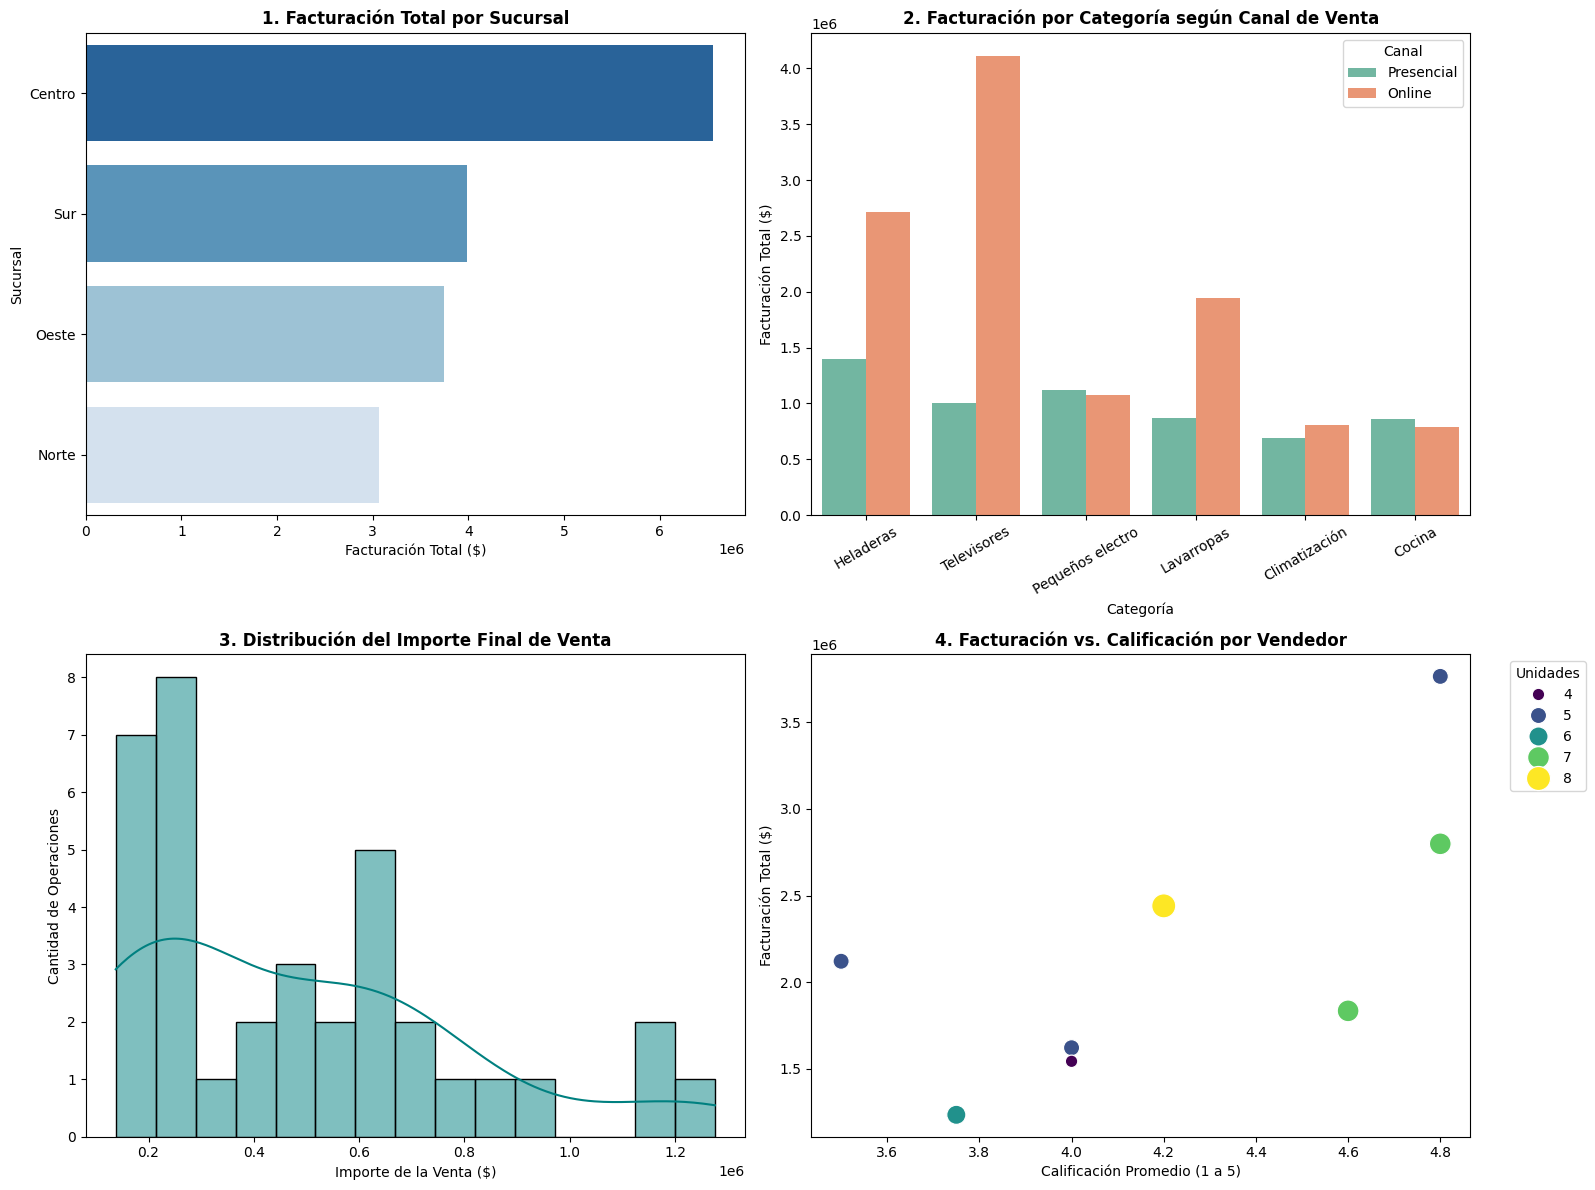

In [39]:
# ----------------------------------------------------
# PUNTO 9: Visualizaciones con Seaborn y Matplotlib
# ----------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Facturación total por Sucursal (Barras horizontales)
sucursal_orden = df.groupby('Sucursal')['Total_Venta'].sum().sort_values(ascending=False).index
sns.barplot(
    data=df,
    x='Total_Venta',
    y='Sucursal',
    order=sucursal_orden,
    estimator=np.sum,
    errorbar=None,
    palette='Blues_r',
    ax=axes[0, 0]
)
axes[0, 0].set_title('1. Facturación Total por Sucursal', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Facturación Total ($)')
axes[0, 0].set_ylabel('Sucursal')

# 2. Facturación por Categoría discriminada por Canal (Online vs Presencial)
sns.barplot(
    data=df,
    x='Categoria',
    y='Total_Venta',
    hue='Canal',
    estimator=np.sum,
    errorbar=None,
    palette='Set2',
    ax=axes[0, 1]
)
axes[0, 1].set_title('2. Facturación por Categoría según Canal de Venta', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Categoría')
axes[0, 1].set_ylabel('Facturación Total ($)')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].legend(title='Canal')

# 3. Distribución de los importes de venta (Histograma + KDE)
sns.histplot(
    df['Total_Venta'],
    kde=True,
    bins=15,
    color='teal',
    ax=axes[1, 0]
)
axes[1, 0].set_title('3. Distribución del Importe Final de Venta', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Importe de la Venta ($)')
axes[1, 0].set_ylabel('Cantidad de Operaciones')

# 4. Calificación Promedio vs Facturación por Vendedor (Dispersión)
sns.scatterplot(
    data=resumen_vendedores,
    x='Calificacion_Promedio',
    y='Facturacion_Total',
    size='Unidades_Vendidas',
    sizes=(80, 300),
    hue='Unidades_Vendidas',
    palette='viridis',
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Facturación vs. Calificación por Vendedor', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Calificación Promedio (1 a 5)')
axes[1, 1].set_ylabel('Facturación Total ($)')
axes[1, 1].legend(title='Unidades', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Punto 9: Justificación y análisis de las visualizaciones
Gráfico 1: Facturación Total por Sucursal

¿Qué pregunta intenta responder? ¿Cuál es el aporte monetario de cada sede física al negocio global?

¿Qué permite observar? Permite comparar rápidamente qué sucursal tracciona el mayor volumen en pesos y detectar posibles asimetrías de rendimiento geográfico.

Gráfico 2: Facturación por Categoría según Canal de Venta (Online vs Presencial)

¿Qué pregunta intenta responder? ¿Qué líneas de productos se venden preferentemente por canal digital y cuáles en sucursal física?

¿Qué permite observar? Compara grupos (categorías) segmentados por canal (hue='Canal'). Permite verificar si los productos voluminosos o costosos siguen demandando atención presencial frente al canal digital.

Gráfico 3: Distribución del Importe Final de Venta

¿Qué pregunta intenta responder? ¿Cómo se concentran los tickets de venta en términos de monto?

¿Qué permite observar? La dispersión y sesgo de los valores de venta, evidenciando si el grueso de las ventas se concentra en compras chicas o medianas con pocos tickets extraordinarios de alto valor.

Gráfico 4: Facturación vs. Calificación por Vendedor

¿Qué pregunta intenta responder? ¿Existe una relación directa entre el volumen de dinero facturado por un vendedor y la satisfacción que reportan sus clientes?

¿Qué permite observar? Cruza el desempeño comercial con la calidad de atención (puntaje 1 al 5) y el volumen de unidades vendidas (tamaño de la burbuja).